In [1]:
# add the path to src2 to the sys.path
import sys
sys.path.append('/home/ubuntu/trilok/Multimodal-Uncertainty-Quantification/src2')
import torch
from PIL import Image
import os
# from inference_utils import generate_explanations_MM
from data_utils import get_vqa_dataloader, VQADataset, vqa_collate_fn
from torch.utils.data import DataLoader
from transformers import AutoProcessor, LlavaForConditionalGeneration

# Updated generate_explanations_MM without batching
def generate_explanations_MM(model, processor, sample, rank, params):
    try:
        torch_device = f'cuda:{rank}' if torch.cuda.is_available() else 'cpu'
        print(f'Using device: {torch_device}')
        
        raw_image = Image.open(sample['image_paths'][0])
        print('Image loaded successfully.')
        
        question_id = sample['question_ids'][0]
        print(f'Question ID: {question_id}')
    
        print(f"Generating explanations for question {question_id}")
    
        total = params['no_of_responses_sampled_per_image']
        print(f'Total responses: {total}')
    
        for i in range(total):
            prompt = sample['promptified_questions'][0]
            image = raw_image
            print(f'Processing response {i + 1}/{total}')
        
            inputs = processor(
                images=image, 
                text=prompt, 
                return_tensors="pt", 
                padding=True, 
                truncation=True
            ).to(torch_device)
            print('Inputs processed and moved to device.')
        
            outputs = model.generate(
                **inputs,
                do_sample=True,
                temperature=params['temperature'],
                top_p=params['top_p'],
                num_beams=params['num_beams'],
                max_new_tokens=params['max_new_tokens'],
                use_cache=False,
                return_dict_in_generate=True,
                output_scores=True
            )
            print('Model generation completed.')
    
            # generated_token_ids = outputs.sequences[0, inputs['input_ids'].shape[-1]:]
            # i am getting empty responses, so trying to get the all the token ids
            generated_token_ids = outputs.sequences[0]
            decoded_outputs = processor.decode(generated_token_ids, skip_special_tokens=True).split('\n')[0]
            transition_scores = model.compute_transition_scores(outputs.sequences, outputs.scores, normalize_logits=True)
    
            sample[f'response_{i}'] = {
                'prompt': prompt,
                'transition_scores': transition_scores[0].cpu().numpy(),
                'generated_token_ids': generated_token_ids.cpu().numpy(),
                'decoded_outputs': decoded_outputs
            }
            print(f'Response {i} generated : ', decoded_outputs)
    
        del inputs, outputs, generated_token_ids, decoded_outputs, transition_scores
        torch.cuda.empty_cache()
        print('Cache cleared.')
        
        return sample
    
    except Exception as e:
        print(f"An error occurred: {e}")

/home/ubuntu/miniconda3/envs/llava/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Initialize model and processor
model_id_llava = "llava-hf/llava-1.5-7b-hf"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_llava = LlavaForConditionalGeneration.from_pretrained(model_id_llava).to(device)
processor_llava = AutoProcessor.from_pretrained(model_id_llava)



Loading checkpoint shards: 100%|██████████| 3/3 [00:02<00:00,  1.24it/s]


In [3]:
config_data = {
    "dataset": "vqa",
    "root_dir": "/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA",
    "image_dir": "train2014",
    "annotation_file": "v1/annotations/mscoco_train2014_annotations_HIGH_agreement_question_types_GROUND.json",
    "question_file": "v1/questions/OpenEnded_mscoco_train2014_questions_RANDOMSEED_42_COUNT_2000_CURRDATE_20241228_170848.json",
    "dataset_type": "json",
    "samples": 2000
}


# Create dataloader
dataloader = DataLoader(VQADataset(config_data), batch_size=1, collate_fn=vqa_collate_fn)

# Get a sample
sample = next(iter(dataloader))

rank = 0


Number of annotations: 25058
Number of questions: 2000


In [4]:
params = {
    # 'inference_batch_size': 20,  # Not used since batching is removed
    'no_of_responses_sampled_per_image': 20,
    'temperature': 1.0,
    'top_p': 0.9,
    'num_beams': 5,
    'max_new_tokens': 50
}
config_logging = {
    'explanation_dir': '/staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/explanations'
}

sample_output = generate_explanations_MM(model_llava, processor_llava, sample, rank, params)

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Using device: cuda:0
Image loaded successfully.
Question ID: 3823162
Generating explanations for question 3823162
Total responses: 20
Processing response 1/20
Inputs processed and moved to device.
Model generation completed.
Response 0 generated :  USER: Answer the questions. Here are few examples:
Processing response 2/20
Inputs processed and moved to device.
Model generation completed.
Response 1 generated :  USER: Answer the questions. Here are few examples:
Processing response 3/20
Inputs processed and moved to device.
Model generation completed.
Response 2 generated :  USER: Answer the questions. Here are few examples:
Processing response 4/20
Inputs processed and moved to device.


KeyboardInterrupt: 

In [8]:
# get all the values in sample data
print(sample.keys())
# dict_keys(['question_ids', 'questions', 'promptified_questions', 'answers', 'all_answers', 'image_ids', 'image_paths', 'response_0', 'response_1', 'response_2'])

# print()
print("promptified_question:", sample['promptified_questions'][0])
print("image path:", sample['image_paths'][0])



dict_keys(['question_ids', 'questions', 'promptified_questions', 'answers', 'all_answers', 'image_ids', 'image_paths', 'response_0', 'response_1', 'response_2'])
promptified_question: USER: Answer the questions. Here are few examples:
        Question: What is the color of the object?
        Answer: The color of the object is red.
        Question: What are the people doing ?
        Answer: The people in the image are playing soccer.
        Question: What animal is in the image?
        Answer: The animal is a cat.
        
        <image>
        What is the man carrying?
        ASSISTANT: 
        
image path: /staging/users/tpadhi1/Multimodal-Uncertainty-Quantification/datasets_/VQA/train2014/COCO_train2014_000000382316.jpg


In [19]:
# prompt = """
# USER:   <image>
# What is the man carrying?
# ASSISTANT: 
# """
prompt = """ USER: Answer the questions. Here are few examples:
        Question: What is the color of the object?
        Answer: The color of the object is red.
        Question: What are the people doing ?
        Answer: The people in the image are playing soccer.
        Question: What animal is in the image?
        Answer: The animal is a cat.
        
        <image>
        What is the man carrying?
        ASSISTANT: 
        """
image_path = sample['image_paths'][0]
image = Image.open(image_path)

inputs = processor_llava(
    images=image, 
    text=prompt, 
    return_tensors="pt", 
    padding=True, 
    truncation=True
).to(device)
print('Inputs processed and moved to device.')

# for i in range(20):
outputs = model_llava.generate(
    **inputs,
    do_sample=True,
    temperature=1.0,
    top_p=params['top_p'],
    num_beams=params['num_beams'],
    max_new_tokens=params['max_new_tokens'],
    use_cache=False,
    return_dict_in_generate=True,
    output_scores=True
)

Inputs processed and moved to device.


In [20]:
# now we can get the generated token ids
generated_token_ids = outputs.sequences[0]
decoded_outputs = processor_llava.decode(generated_token_ids, skip_special_tokens=True)

print("Generated response:", decoded_outputs)
# got empty response for temperature 1.0, so trying with 0.5
# with temperature 0.5, got the response
# The man is carrying a bicycle and an umbrella.
# so I tried with temperature 1.0, also i got the response, but here the prompt is different, it doesn't have the ICL examples
# so I tried the prompt with ICL examples, and got the response, but temperature 0.5 is giving the response, so lets try with 1.0
# so I tried with temperature 1.0, also i got the response, with ICL examples in the prompt

Generated response:  USER: Answer the questions. Here are few examples:
        Question: What is the color of the object?
        Answer: The color of the object is red.
        Question: What are the people doing ?
        Answer: The people in the image are playing soccer.
        Question: What animal is in the image?
        Answer: The animal is a cat.
        
         
        What is the man carrying?
        ASSISTANT: 
        
        The man is carrying a bicycle and an umbrella.


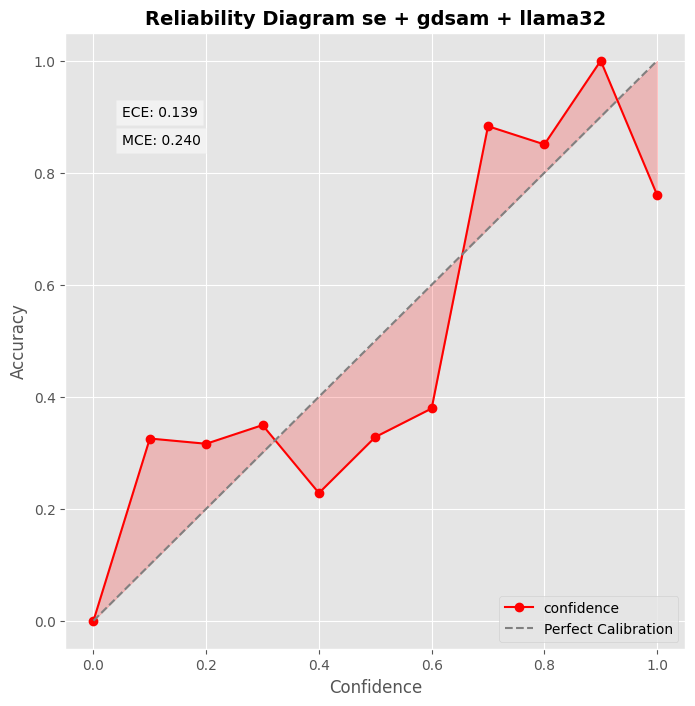

In [10]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Generate linear data
# confidence = np.linspace(0, 1, 11)  # Confidence bins (0 to 1)
# accuracy = confidence  # Linear relation for perfect calibration

# # Expected Calibration Error (ECE) and Maximum Calibration Error (MCE)
# ECE = 0.0  # Since it's perfectly calibrated
# MCE = 0.0  # Maximum error is 0

# # Plot the reliability diagram
# plt.figure(figsize=(8, 8))
# plt.plot(confidence, accuracy, 'o-', color='red', label='Reliability (Perfect Calibration)')
# plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')  # Diagonal line

# # Fill area between curve and diagonal
# plt.fill_between(confidence, accuracy, confidence, color='red', alpha=0.2)

# # Add labels, title, and legend
# plt.title('Reliability Diagram (Perfect Calibration)', fontsize=14, weight='bold')
# plt.xlabel('Confidence')
# plt.ylabel('Accuracy')
# plt.legend(loc='lower right')

# # Add ECE and MCE as text
# plt.text(0.05, 0.9, f"ECE: {ECE:.3f}", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
# plt.text(0.05, 0.85, f"MCE: {MCE:.3f}", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

# # Show the plot
# plt.grid(True)
# plt.show()
import numpy as np
import matplotlib.pyplot as plt

# --------------------------
# Generate data with noise
# --------------------------
np.random.seed(42)  # For reproducibility
confidence = np.linspace(0, 1, 11)  # Confidence bins (0 to 1)

# Add random noise to simulate slight deviations
# noise = np.random.uniform(-0.05, 0.05, size=confidence.shape)  # Noise range [-0.05, 0.05]
noise = np.random.uniform(-0.25, 0.25, size=confidence.shape)  # Noise range [-0.15, 0.15]
accuracy = confidence + noise  # Add noise
accuracy = np.clip(accuracy, 0, 1)  # Ensure accuracy stays within [0, 1]

# --------------------------
# Calculate ECE and MCE
# --------------------------
ECE = np.mean(np.abs(accuracy - confidence))  # Expected Calibration Error
MCE = np.max(np.abs(accuracy - confidence))  # Maximum Calibration Error

# --------------------------
# Plot the reliability diagram
# --------------------------
plt.figure(figsize=(8, 8))
plt.plot(confidence, accuracy, 'o-', color='red', label='confidence')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect Calibration')  # Diagonal line

# Fill area between curve and diagonal
plt.fill_between(confidence, accuracy, confidence, color='red', alpha=0.2)

# Add labels, title, and legend
plt.title('Reliability Diagram se + gdsam + llama32', fontsize=14, weight='bold')
plt.xlabel('Confidence')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Add ECE and MCE as text
plt.text(0.05, 0.9, f"ECE: {ECE:.3f}", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))
plt.text(0.05, 0.85, f"MCE: {MCE:.3f}", fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

# Show the plot
plt.grid(True)
plt.show()